# Travel Planner Generator

This notebook implements an AI-powered meta-software development workflow for the DTS114TC coursework. It turns a travel planning business problem into software artefacts, including SDLC documentation, UML diagrams, a Flask API, a travel planning website, and deployment assets.



## Environment Requirements

To run this notebook, use a Python/Jupyter environment with `requests`, `python-dotenv`, `flask`, `flask-cors`, and `pytest` installed. An APIFree API key should be provided through a `.env` file or environment variable as `APIFREE_API_KEY`. The notebook checks both the project root `.env` and `Task1/.env`, so it can still run if the key file is kept beside this notebook. Internet access is required for APIFree and PlantUML diagram rendering. Docker Desktop is only required for the deployment step in Task2. The recommended submission layout is `Task1/travel_planner_generator.ipynb`, but the notebook can also run from a standalone folder and will generate `Task2` relative to the current working directory.



## Development Methodology

The project follows an AI-driven development lifecycle supported by Agile-style iteration. The workflow is organised into three phases: Inception, Construction, and Operation.



## Setup

This section prepares imports, output folders, and APIFree API configuration. The notebook requires an APIFree API key for AI generation.



In [1]:
from pathlib import Path
import json
import os

# Resolve paths so the notebook can run from the project root or from Task1.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "task1" else CURRENT_DIR
print(f"Notebook working directory: {CURRENT_DIR}")
print(f"Project output root: {PROJECT_ROOT}")
TASK1_DIR = PROJECT_ROOT / "Task1"
ARTIFACTS_DIR = TASK1_DIR / "artifacts"
APP_DIR = ARTIFACTS_DIR / "app"
DOCS_DIR = ARTIFACTS_DIR / "docs"
UML_DIR = ARTIFACTS_DIR / "uml"
ASSETS_DIR = APP_DIR / "static" / "images"

# All generated coursework artefacts are kept under Task1/artifacts.
for directory in [APP_DIR, DOCS_DIR, UML_DIR, ASSETS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

env_candidates = [PROJECT_ROOT / ".env", CURRENT_DIR / ".env", PROJECT_ROOT / "Task1" / ".env"]

try:
    from dotenv import load_dotenv
    loaded_env_files = []
    for env_path in env_candidates:
        if env_path.exists():
            load_dotenv(env_path, override=False)
            loaded_env_files.append(str(env_path))
    print("Loaded .env file(s): " + ", ".join(loaded_env_files) if loaded_env_files else "No .env file found; using existing environment variables only.")
except ImportError:
    print("python-dotenv is not installed. The notebook will use existing environment variables only.")

API_KEY = os.getenv("APIFREE_API_KEY")
APIFREE_BASE_URL = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1")
APIFREE_MODEL = os.getenv("APIFREE_MODEL", "gpt-5-mini")
APIFREE_IMAGE_MODEL = os.getenv("APIFREE_IMAGE_MODEL", "google/nano-banana-2")

print("APIFree API key detected" if API_KEY else "APIFREE_API_KEY is not configured yet")
print(f"Text model: {APIFREE_MODEL}")
print(f"Image model: {APIFREE_IMAGE_MODEL}")



Notebook working directory: c:\Users\Qingyi Yang\Desktop\2469447_Qingyi.Yang\Task1
Project output root: c:\Users\Qingyi Yang\Desktop\2469447_Qingyi.Yang
Loaded .env file(s): c:\Users\Qingyi Yang\Desktop\2469447_Qingyi.Yang\.env
APIFree API key detected
Text model: gpt-5-mini
Image model: google/nano-banana-2


# Phase 1: Inception

Inception converts the business problem into software development context, including a problem statement, personas, requirements, and user stories.



In [2]:
business_problem = """
A small travel agency needs a web application that helps tourists generate personalised city travel itineraries. Users should be able to enter a destination, trip length, budget level, and interests. The system should return a clear day-by-day itinerary and present it through both a Flask API and a website.
""".strip()

quality_contract = """
Stable generation contract for this coursework software:
- The generated Flask API must expose GET /health and POST /api/itinerary.
- POST /api/itinerary must accept destination, days, budget, interests, and travel_style.
- A successful itinerary response must contain top-level destination, days, budget, interests, travel_style, overview, itinerary, and tips.
- The itinerary list length must equal days.
- Itinerary activities must not repeat the same generic fallback each day; rotate morning, afternoon, and evening items using destination, day number, time slot, and user interests.
- Expand each interest into several concrete activities before building the itinerary, so a multi-day trip does not visibly repeat the same three activities.
- For example, food can become breakfast street-food lane, local market tasting, signature restaurant meal, dessert and tea stop, and evening snack street.
- For example, outdoor can become lakefront walk, city park reset, scenic viewpoint, and garden or nature trail.
- Each day should have a different theme or planning focus where possible.
- Activity titles/descriptions must be human-readable strings, never raw dictionaries or [object Object].
- Estimated costs should be numeric values adjusted by budget, not strings such as low/medium/high.
- Each itinerary day must include day, morning, afternoon, evening, and budget_note.
- Activity data may be dictionaries, but the frontend must render readable fields and must never display [object Object].
- Invalid input must return HTTP 400 with a JSON error object.
- The generated frontend must not create its own image preview area; image integration is handled later by the frontend image contract agent.
- The generated frontend should use stable IDs: plannerForm, destination, days, budget, interests, travel_style, resultsContainer, daysContainer, formMessage, errorMessage.
- The generated frontend should use stable functions: collectFormData, validateFormData, setLoading, showError, renderItinerary, renderDay, renderActivity, and formatActivityText.
- Generated code should be deterministic enough for automated pytest checks and Docker deployment.
""".strip()

project_context = {
    "project_name": "Travel Planner Generator",
    "business_problem": business_problem,
    "quality_contract": quality_contract,
    "demo_destination": "Kyoto",
    "demo_days": 3,
    "demo_budget": "medium",
    "demo_interests": ["culture", "food", "nature"],
}

print(project_context["business_problem"])
print("Quality contract loaded for AI generation prompts")




A small travel agency needs a web application that helps tourists generate personalised city travel itineraries. Users should be able to enter a destination, trip length, budget level, and interests. The system should return a clear day-by-day itinerary and present it through both a Flask API and a website.
Quality contract loaded for AI generation prompts


## Generated SDLC Documentation

This section uses the APIFree API to create the problem statement, personas, requirements, PRD, and user stories.



In [3]:
def generate_text(task_name, prompt, context, max_retries=3):
    """Generate text with the APIFree chat endpoint, retrying transient API failures."""
    api_key = os.getenv("APIFREE_API_KEY")
    base_url = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1")
    model = os.getenv("APIFREE_MODEL", "gpt-5-mini")

    if not api_key:
        raise RuntimeError("APIFREE_API_KEY is not configured. Add it to the environment before running this notebook.")

    import requests
    import time

    # Shared APIFree payload used by the notebook to generate documents, UML, and code.
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": "You are a software engineering assistant producing concise coursework artefacts."},
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.3,
    }

    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            # A longer timeout is used because model generation can be slow during busy periods.
            response = requests.post(
                f"{base_url.rstrip('/')}/chat/completions",
                headers={
                    "Authorization": f"Bearer {api_key}",
                    "Content-Type": "application/json",
                },
                json=payload,
                timeout=600,
            )
            response.raise_for_status()
            data = response.json()
            if "error" in data:
                message = data["error"].get("message", data["error"])
                last_error = RuntimeError(f"APIFree generation failed for {task_name}: {message}")
                # APIFree sometimes returns temporary server errors inside a 200 JSON body.
                if attempt < max_retries and any(word in str(message).lower() for word in ["server", "timeout", "temporar", "rate"]):
                    print(f"APIFree temporary error for {task_name}; retrying {attempt}/{max_retries}...")
                    time.sleep(5 * attempt)
                    continue
                raise last_error
            if "choices" not in data:
                raise RuntimeError(f"APIFree response for {task_name} did not include choices: {data}")
            return data["choices"][0]["message"]["content"].strip()
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError, requests.exceptions.HTTPError) as exc:
            last_error = exc
            status_code = getattr(getattr(exc, "response", None), "status_code", None)
            transient = status_code in {429, 500, 502, 503, 504} or status_code is None
            if attempt < max_retries and transient:
                print(f"APIFree request failed for {task_name}; retrying {attempt}/{max_retries}...")
                time.sleep(5 * attempt)
                continue
            raise RuntimeError(f"APIFree generation failed for {task_name} after {attempt} attempt(s): {exc}") from exc

    raise RuntimeError(f"APIFree generation failed for {task_name} after {max_retries} attempts: {last_error}")





In [4]:
problem_statement_prompt = f"""
Given the business problem below, write one concise software engineering problem statement.
Mention that the software must generate stable Flask API and website artefacts suitable for automated testing and Docker deployment.

Business problem:
{business_problem}

Quality contract:
{quality_contract}
""".strip()

personas_prompt = f"""
Generate 3-4 concise user personas for this software project.
Each persona should include the user's role, goal, main concern, and one acceptance expectation related to clear itinerary output or image generation.

Business problem:
{business_problem}

Quality contract:
{quality_contract}
""".strip()

requirements_prompt = f"""
Write functional and non-functional requirements for this project in markdown.
Keep the scope suitable for a coursework Flask API and website.
Include requirements for stable API response schema, frontend object rendering, AI image generation, testing, CI, and Docker deployment.

Business problem:
{business_problem}

Quality contract:
{quality_contract}
""".strip()

prd_prompt = f"""
Write a concise Product Requirements Document for this project with headings:
Overview, Goals, Scope, Constraints, Success Criteria.
The PRD must include API stability, frontend readability, AI image integration, automated tests, and Docker deployment as success criteria.

Business problem:
{business_problem}

Quality contract:
{quality_contract}
""".strip()

user_stories_prompt = f"""
Return only valid JSON for 3-5 Agile user stories using this schema:
{{
  "user_stories": [
    {{
      "id": "US1",
      "role": "...",
      "goal": "...",
      "benefit": "...",
      "acceptance_criteria": ["...", "..."]
    }}
  ]
}}

Business problem:
{business_problem}

Quality contract:
{quality_contract}
""".strip()

generated_docs = {
    "problem_statement": generate_text("problem_statement", problem_statement_prompt, project_context),
    "personas": generate_text("personas", personas_prompt, project_context),
    "requirements": generate_text("requirements", requirements_prompt, project_context),
    "prd": generate_text("prd", prd_prompt, project_context),
    "user_stories": generate_text("user_stories", user_stories_prompt, project_context),
}

for name, content in generated_docs.items():
    suffix = "json" if name == "user_stories" else "md"
    output_path = DOCS_DIR / f"{name}.{suffix}"
    output_path.write_text(content, encoding="utf-8")
    print(f"Saved {output_path.relative_to(PROJECT_ROOT)}")




APIFree request failed for problem_statement; retrying 1/3...
APIFree request failed for problem_statement; retrying 2/3...


RuntimeError: APIFree generation failed for problem_statement after 3 attempt(s): HTTPSConnectionPool(host='api.apifree.ai', port=443): Max retries exceeded with url: /v1/chat/completions (Caused by ProxyError('Unable to connect to proxy', NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000017D88B00550>: Failed to establish a new connection: [WinError 10061] 由于目标计算机积极拒绝，无法连接。')))

In [ ]:
print("Problem statement:\n")
print(generated_docs["problem_statement"])

print("\nUser stories preview:\n")
print(generated_docs["user_stories"][:800])



Problem statement:

Build a travel-agency web app that generates personalised multi-day city itineraries via a Flask backend and a browser frontend. The Flask API must expose GET /health and POST /api/itinerary; POST must accept destination, days, budget, interests, and travel_style and return JSON with top-level fields destination, days, budget, interests, travel_style, overview, itinerary, and tips. The itinerary must be a list whose length equals days and each day must include day, morning, afternoon, evening, and budget_note. Generate activities by expanding each user interest into several concrete activities and rotate morning/afternoon/evening items using destination, day number, time slot, and interests so the same generic fallback does not repeat; each day should have a distinct theme where possible. Activity titles and descriptions must be human-readable strings (never raw dictionaries or “[object Object]”); estimated costs must be numeric and adjusted by budget. Invalid input

# Phase 2: Construction

Construction generates UML diagrams, Flask API code, website code, tests, Docker deployment files, and AI-generated image support. A lightweight frontend image contract agent is used after frontend generation to check that the generated website includes the default AI image, the destination image area, and the dynamic image API call without replacing the whole generated application.




## Generated UML and Application Code

This section generates UML diagrams from the SDLC documentation and renders them through the public PlantUML server.



In [ ]:
import re
import zlib
from urllib.parse import quote


def extract_plantuml(text):
    """Extract PlantUML code from a model response."""
    fenced_match = re.search(r"```(?:plantuml|puml)?\s*(.*?)```", text, re.DOTALL | re.IGNORECASE)
    if fenced_match:
        text = fenced_match.group(1).strip()
    start = text.find("@startuml")
    end = text.find("@enduml")
    if start == -1 or end == -1:
        raise ValueError("The generated UML response does not contain @startuml and @enduml.")
    plantuml = text[start:end + len("@enduml")].strip()
    return plantuml


def validate_ai_plantuml(diagram_name, plantuml_text):
    """Validate AI-generated PlantUML without replacing it with a manual fallback."""
    forbidden = [r"(?m)^\s*stop\s*$", r"(?m)^\s*start\s*$", r"(?m)^\s*partition\b", r"(?m)^\s*fork\b"]
    if diagram_name == "sequence_diagram" and any(re.search(pattern, plantuml_text) for pattern in forbidden):
        raise ValueError(f"AI-generated {diagram_name} contains activity-diagram syntax. Re-run this cell to regenerate valid sequence PlantUML.")
    if plantuml_text.count("@startuml") != 1 or plantuml_text.count("@enduml") != 1:
        raise ValueError(f"AI-generated {diagram_name} must contain exactly one @startuml and one @enduml.")
    return plantuml_text


def plantuml_encode(text):
    """Encode PlantUML text for the PlantUML server."""
    data = zlib.compress(text.encode("utf-8"))[2:-4]
    alphabet = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz-_"

    def encode_3bytes(bytes_chunk):
        if len(bytes_chunk) < 3:
            bytes_chunk += b"\x00" * (3 - len(bytes_chunk))
        b1, b2, b3 = bytes_chunk
        c1 = b1 >> 2
        c2 = ((b1 & 0x3) << 4) | (b2 >> 4)
        c3 = ((b2 & 0xF) << 2) | (b3 >> 6)
        c4 = b3 & 0x3F
        return alphabet[c1] + alphabet[c2] + alphabet[c3] + alphabet[c4]

    return "".join(encode_3bytes(data[i:i + 3]) for i in range(0, len(data), 3))


def render_plantuml_png(plantuml_text, output_path):
    """Render a PlantUML diagram to PNG using the public PlantUML server."""
    import requests
    import base64

    encoded = plantuml_encode(plantuml_text)
    url = f"https://www.plantuml.com/plantuml/png/{encoded}"
    try:
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        output_path.write_bytes(response.content)
        return url
    except Exception as error:
        raise RuntimeError(f"PlantUML PNG rendering failed for {output_path.name}: {error}") from error



In [ ]:
def compact_for_uml_prompt(text, limit=900):
    """Keep UML prompts short so the model does not copy JSON or long prose into PlantUML."""
    compact = " ".join(str(text).replace("\r", " ").replace("\n", " ").split())
    return compact[:limit]


# Compress generated requirements into short context so PlantUML output stays valid.
uml_context = "\n\n".join([
    "Business Problem:\n" + compact_for_uml_prompt(business_problem, 700),
    "Problem Statement:\n" + compact_for_uml_prompt(generated_docs["problem_statement"], 900),
    "Requirements:\n" + compact_for_uml_prompt(generated_docs["requirements"], 900),
    "User Stories Summary:\nTourist enters fixed preference choices and receives a readable itinerary; the website requests an AI destination image; tests and Docker support verification and deployment.",
])

# The UML prompts use strict syntax rules because PlantUML rejects small syntax mistakes.
uml_prompts = {
    "use_case_diagram": f"""
Generate a UML use case diagram in valid PlantUML for the Travel Planner Generator.
Include actors such as Tourist and Travel Agency Assistant.
Include use cases for entering preferences, validating input, generating an itinerary, viewing readable day plans, requesting a destination image, running tests, and deploying with Docker.
Use this exact safe PlantUML style with no semicolons and no stereotypes: actor "Tourist" as Tourist; rectangle "Travel Planner Generator" {{ usecase "Enter Preferences" as UC1 }}; Tourist --> UC1; UC1 ..> UC2 : includes.
Use aliases for every use case, such as UC1, UC2, UC3. Do not draw arrows directly to quoted labels.
Use only standard use-case syntax: actor, rectangle, usecase, -->, and ..> : includes relationships.
Strict syntax rules: do not use semicolons; do not use <<include>>; do not use stereotypes; do not use notes; do not use skinparam; do not use direction commands; do not use package; do not use JSON, HTML, code snippets, markdown, braces-heavy examples, or multiline labels.
Every relationship line must look like one of these examples: Tourist --> UC1 or UC1 ..> UC2 : includes.
Keep labels short and avoid special symbols except spaces, hyphens, parentheses, and slashes.
Return only PlantUML code from @startuml to @enduml. Do not include markdown fences or commentary.

{uml_context}
""".strip(),
    "sequence_diagram": f"""
Generate a UML sequence diagram in valid PlantUML for the main user journey.
Show the User submitting travel preferences to the Website, the Website validating input, the Website calling the Flask API, the Flask API returning a stable itinerary schema, the Website rendering readable activity fields, the Website calling the image endpoint, the Flask API calling APIFree for the image, and the Website displaying both itinerary and image.
Use this safe PlantUML style: actor User; participant Website; participant "Flask API" as API; User -> Website: Submit preferences; Website -> API: POST /api/itinerary; API --> Website: Itinerary response.
Use aliases for participants with spaces. Keep every message on one line.
Write each PlantUML statement on its own separate line. Do not combine actor, participant, or message statements on one line.
Do not use semicolons anywhere in the sequence diagram.
Start with separate lines exactly like: actor User, participant Website, participant \"Flask API\" as API, participant APIFree.
Use only standard sequence-diagram syntax: actor, participant, ->, -->, activate, deactivate, alt, else, end, and short notes.
Do not use activity-diagram commands such as stop, start, fork, partition, repeat, while, if, endif, or swimlanes.
Do not include JSON blocks, HTML, code snippets, braces-heavy payload examples, markdown, or very long messages.
Keep every message label short. Use plain text such as POST /api/itinerary rather than full JSON payloads.
Return only PlantUML code from @startuml to @enduml. Do not include markdown fences or commentary.

Quality contract:
{quality_contract}
""".strip(),
}

generated_uml = {}
for diagram_name, prompt in uml_prompts.items():
    print(f"Generating {diagram_name}...")
    uml_response = generate_text(diagram_name, prompt, project_context)
    plantuml_text = extract_plantuml(uml_response)
    plantuml_text = validate_ai_plantuml(diagram_name, plantuml_text)
    generated_uml[diagram_name] = plantuml_text

    puml_path = UML_DIR / f"{diagram_name}.puml"
    png_path = UML_DIR / f"{diagram_name}.png"
    puml_path.write_text(plantuml_text, encoding="utf-8")
    render_url = render_plantuml_png(plantuml_text, png_path)

    print(f"Saved {puml_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved {png_path.relative_to(PROJECT_ROOT)}")
    print(f"Rendered with {render_url}\n")




Generating use_case_diagram...
Saved Task1\artifacts\uml\use_case_diagram.puml
Saved Task1\artifacts\uml\use_case_diagram.png
Rendered with https://www.plantuml.com/plantuml/png/TPBBJiCm44Nt_efHzgr4yv9Oe5O4eUugLDYFd25Ok4xnWof2_3lJr8cC2eiuapl79tRYjVDeVJXeWTBt5h9z7wnoFWDq4EkvPV6JD6mwCdA0ZNFSGtD1voTXIVAzqpHFs6aqXYmy4e_8gWo-10H74XrJ3yPpSsVfbIoRoOt2v_kRX7b1hLhq15jp33u2gmI8RWQyEbTsY52UMXITeC5XND7qcY81dkWZaFFGyA0CUjKRs1wmeyYMAHiCx9cRF5NIQ-Ye-m5Eohz1qyjtiX6gnRU8NnKMYxjnbtp1SdckLt0BoaWTMd8Svt_74vsdyMzfaSmk_iTASMvVi3B5vhyPmVmggQwIccLrb5MfR4scvGFs0m00

Generating sequence_diagram...
Saved Task1\artifacts\uml\sequence_diagram.puml
Saved Task1\artifacts\uml\sequence_diagram.png
Rendered with https://www.plantuml.com/plantuml/png/ZPB1Ri8m38RlUGgBE-BEOMBJneGqQGZ6TZQj1zRID7BIJhpzd9HM53PfXpQjyzd-VoUB455YKrc3HQm5Te74U0rnmHvTX0_Q1uuqYasM5iCNtAzN4y2Grj6s_Y-5oAHQCBthIynXs-mhZk25Fad85HJCUM-4lQFb4ZN8pZVHe8twrQRW9PwgQybZ_Grjby2r0nAfnP0D13SPgciEwzVj6ypGyumZEnAKKxBERMgOdEWpm0yDsn86449nf0exv5BnQY24WgzT85FIgEflFZ

In [ ]:
for diagram_name, plantuml_text in generated_uml.items():
    print(f"--- {diagram_name} ---")
    print(plantuml_text[:800])
    print()



--- use_case_diagram ---
@startuml
actor "Tourist" as Tourist
actor "Travel Agency Assistant" as Assistant
rectangle "Travel Planner Generator" {
 usecase "Enter Preferences" as UC1
 usecase "Validate Input" as UC2
 usecase "Generate Itinerary" as UC3
 usecase "View Day Plans" as UC4
 usecase "Request Destination Image" as UC5
 usecase "Run Tests" as UC6
 usecase "Deploy with Docker" as UC7
}
Tourist --> UC1
UC1 ..> UC2 : includes
UC3 ..> UC2 : includes
UC1 ..> UC3 : includes
Tourist --> UC4
UC3 ..> UC4 : includes
Tourist --> UC5
UC4 ..> UC5 : includes
Assistant --> UC3
Assistant --> UC6
Assistant --> UC7
UC7 ..> UC6 : includes
@enduml

--- sequence_diagram ---
@startuml
actor User
participant Website
participant "Flask API" as API
participant APIFree
User -> Website: Submit preferences
Website -> Website: Validate input
alt invalid
Website -> User: Show validation error
else valid
Website -> API: POST /api/itinerary
activate API
API -> API: Build itinerary schema
API --> Website: Itin

Displaying Task1\artifacts\uml\use_case_diagram.png


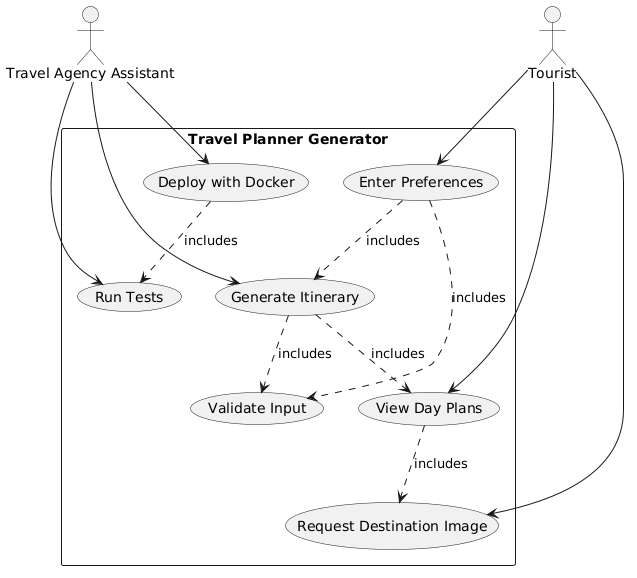

Displaying Task1\artifacts\uml\sequence_diagram.png


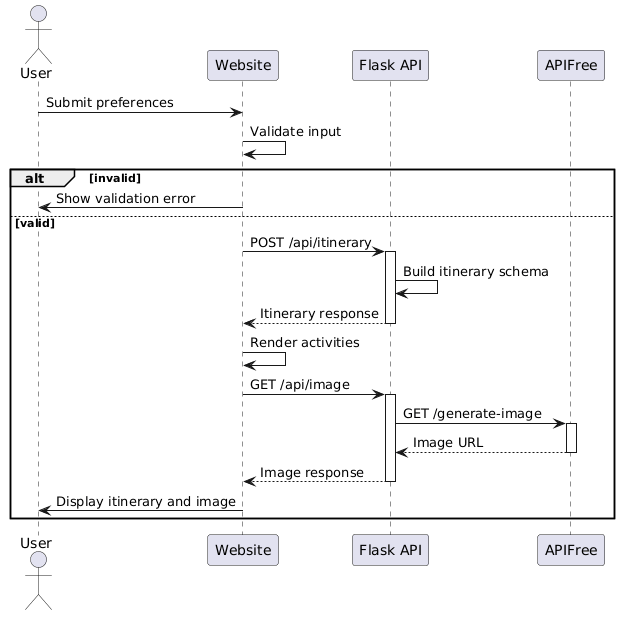

In [ ]:
from IPython.display import Image, display

for diagram_name in generated_uml:
    png_path = UML_DIR / f"{diagram_name}.png"
    print(f"Displaying {png_path.relative_to(PROJECT_ROOT)}")
    display(Image(filename=str(png_path)))



## Generated Flask API

This section generates a functional Flask API for the travel planner. The generated API is saved into `Task1/artifacts/app`.



In [ ]:
def extract_code_block(text, language=None):
    """Extract code from a fenced markdown block, or return the raw text."""
    if language:
        pattern = rf"```{language}\s*(.*?)```"
        match = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        if match:
            return match.group(1).strip()

    match = re.search(r"```(?:\w+)?\s*(.*?)```", text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip()


# This prompt defines a stable backend contract so generated Flask code works with tests and the frontend.
flask_api_prompt = f"""
Generate a compact, testable Python Flask application for a travel itinerary planner.
Return only Python code, with no markdown explanation.

Required behaviour:
- Use Flask and flask_cors.CORS.
- Provide GET /health returning JSON exactly containing status="ok".
- Provide GET / returning a short JSON description of the API.
- Provide POST /api/itinerary accepting JSON fields: destination, days, budget, interests, travel_style.
- Validate that destination is provided and days is an integer between 1 and 14.
- Invalid input must return HTTP 400 with a JSON object containing at least one of these keys: error, message, details, errors, error_code, or fields.
- Successful POST /api/itinerary must return HTTP 200 or 201 with top-level JSON keys: destination, days, budget, interests, travel_style, overview, itinerary, and tips.
- The itinerary list length must equal the requested days value.
- Each itinerary item must be a dictionary with day, morning, afternoon, evening, and budget_note.
- morning, afternoon, and evening should be activity dictionaries, not strings. Each activity should include at least title or name, description, and estimated_cost.
- Normalise interests before planning: map nature/outdoors to outdoor, museum to museums, history to culture, dining to food, and preserve valid interests such as nightlife, family, and shopping instead of dropping them.
- Every generated day must include valid morning, afternoon, and evening activity objects so frontend rendering and pytest checks do not receive empty lists or None-only days.
- The activity variety requirement still matters: each supported interest should be able to produce at least 42 distinct activity combinations in total, with at least 14 morning-safe, 14 afternoon-safe, and 14 evening-safe title combinations. Do not hard-code all 42 as literal dictionaries; generate them programmatically from compact phrase banks and helper functions.
- For each interest, define slot-aware phrase banks: several title starters plus several morning, afternoon, and evening activity phrases. Use loops or deterministic indexing to create the required 14+ combinations per slot for up to 14 days.
- If the user selects only one interest, the itinerary must still vary the activity titles across days. For trips of 14 days or fewer, do not repeat a title within the same time slot unless the slot-specific bank is exhausted.
- Implement deterministic anti-repetition logic using a used_titles_by_slot dictionary such as {{'morning': set(), 'afternoon': set(), 'evening': set()}} plus a per-slot rotation index.
- When selecting an activity for a slot, first choose from the selected interest's slot-specific bank and skip titles already used in that slot. If all titles are used, then allow reuse with a day-specific variation in the title or description.
- Do not write while loops that depend on creating new unique titles without a maximum attempt limit. If generating many titles from prefix/phrase lists, use nested for loops or add a clear maximum attempts guard so the API can never hang.
- Do not add random numbers, hash values, IDs, or numeric suffixes to activity titles. Bad examples: Cultural Performance (508), Museum Visit #2, Food Tour 73. Variation must come from genuinely different activity names and descriptions.
- Activity titles should look natural to a user, for example Tea House Tasting, Heritage Lane Walk, Local Breakfast Market, Evening Light Walk.
- Include a theme field for each day, such as arrival and orientation, local culture, food and neighbourhoods, scenery and slower pace, hidden corners, or final highlights.
- For food, include varied options such as breakfast street-food lane, morning produce market, bakery stop, tea house tasting, neighbourhood noodle stop, casual lunch counter, cooking mini-workshop, dessert cafe, signature restaurant meal, food hall tasting, riverside cafe, supper club, and evening snack street.
- For outdoor, include varied options such as lakefront walk, river walk, city park reset, scenic viewpoint, garden trail, riverside cycling, botanical corner, old street photo walk, picnic stop, hill path, sunset promenade, and evening waterfront walk.
- For culture, museums, family, shopping, and nightlife, also support at least 42 total generated activity combinations per interest bank, split across morning/afternoon/evening as described above.
- For nightlife and family interests, include concrete evening/family activities instead of falling back to cultural landmark visit.
- Time-of-day logic is required: night markets, bars, cocktails, rooftops, live music, evening lights, and performances must be placed in evening, never in morning or afternoon.
- Afternoon activities should be suitable daytime activities such as museums, cafes, gardens, markets, shopping streets, workshops, parks, viewpoints, or neighbourhood walks.
- Each activity object must use a consistent schema: title, name, description, time_window, duration_minutes or duration_hours, estimated_cost, and location.
- If activity banks use tuples or lists, the order must be exactly (title, description, estimated_cost, location, duration_minutes). make_activity must unpack this order correctly and must catch TypeError/ValueError if estimated_cost is not numeric.
- The overview string must include the submitted destination name.
- The code must not depend on randomness for schema shape. Randomness is allowed only for choosing labels/content, not for whether required fields exist.
- Support any destination string entered by the user; do not restrict the API to a fixed list of cities.
- It is acceptable to use generic travel-planning templates when real destination data is unavailable.
- Do not call external travel APIs inside the generated Flask app.

Implementation constraints for reliability:
- Do not use Flask g, session, current_app, or request-scoped global variables. Keep route state in local variables only.
- Use the exact helper function names and signatures below. Do not invent alternative helper names for the same responsibilities.
- Define exactly one normalize_budget_value(budget) function. It must use str(budget), return only low, medium, or high, and must never reference undefined local variables such as b before assignment.
- Define exactly one normalize_interests(raw) function. It must return a list of lowercase strings, map nature/outdoors to outdoor, museum to museums, history to culture, dining to food, and keep nightlife/family/shopping when provided.
- Define exactly one make_activity(activity_source, time_window="activity", budget="medium", destination="") function. It must safely accept either a POI dictionary or a category string. It must never use a dict as a key in another dictionary.
- Define exactly one build_itinerary(destination, days, budget, interests, travel_style) function. It must return the itinerary list with exactly one dictionary per day.
- Define exactly one create_error(message, status_code=400, field=None) helper for validation errors.
- Do not define make_activity twice, normalize_interests twice, normalize_budget_value twice, or duplicate route functions.
- Route functions must be named health(), index(), and api_itinerary().
- If using POI dictionaries, make_activity must read fields using .get(), such as name/title, desc/description, category, duration, and budget.
- Budget values should be normalised to lowercase strings low, medium, or high.
- Interests should always become a list of lowercase strings before planning.
- Before returning a response, ensure the response object is JSON serialisable and contains no sets, functions, or custom objects.
- Keep the code concise. Prefer reusable helper functions and compact phrase banks over long hard-coded lists.
- Include an if __name__ == '__main__' block running on host 0.0.0.0 and port from the PORT environment variable, default 5000.

The generated code should be able to pass tests that call:
- GET /health
- POST /api/itinerary with destination="Paris", days=2, budget="medium", interests=["culture", "food"], travel_style="balanced"
- POST /api/itinerary with days=30 and expect HTTP 400

Project context:
{uml_context}

Quality contract:
{quality_contract}
""".strip()

flask_code_response = generate_text("flask_api", flask_api_prompt, project_context)
flask_code = extract_code_block(flask_code_response, "python")

app_py_path = APP_DIR / "app.py"
app_py_path.write_text(flask_code, encoding="utf-8")
print(f"Saved {app_py_path.relative_to(PROJECT_ROOT)}")

requirements_text = """Flask==2.3.3
flask-cors==4.0.0
requests==2.31.0
"""
requirements_path = APP_DIR / "requirements.txt"
requirements_path.write_text(requirements_text, encoding="utf-8")
print(f"Saved {requirements_path.relative_to(PROJECT_ROOT)}")








Saved Task1\artifacts\app\app.py
Saved Task1\artifacts\app\requirements.txt


In [ ]:
print(flask_code[:1200])



from flask import Flask, jsonify, request
from flask_cors import CORS
import os

app = Flask(__name__)
CORS(app)

def normalize_budget_value(budget):
    s = str(budget).lower()
    if "low" in s or "budget" in s:
        return "low"
    if "high" in s or "lux" in s or "premium" in s:
        return "high"
    return "medium"

def normalize_interests(raw):
    if raw is None:
        return []
    if isinstance(raw, str):
        raw_list = [raw]
    else:
        raw_list = list(raw)
    out = []
    for it in raw_list:
        if not isinstance(it, str):
            continue
        v = it.strip().lower()
        if v in ("nature", "outdoors"):
            out.append("outdoor")
        elif v == "museum":
            out.append("museums")
        elif v == "history":
            out.append("culture")
        elif v == "dining":
            out.append("food")
        elif v in ("nightlife", "family", "shopping", "food", "outdoor", "museums", "culture"):
            out.append(v)
    

## Generated Website Frontend

This section generates a single `index.html` file that is served by the Flask app and integrated with the generated API.



In [ ]:
# This prompt defines the required frontend IDs and rendering functions used by tests and later integration checks.
html_prompt = f"""
Generate a complete, production-ready HTML5 webpage for a Travel Planner Generator.
Return only the complete HTML document, with no markdown explanation.

General requirements:
- Use a single HTML file with inline CSS and inline JavaScript.
- Build a polished travel-planning interface, not a marketing landing page.
- The page must work when served by Flask from the same folder as app.py.
- Keep all text concise and professional.
- Do not use external images or map APIs.

Fixed HTML element contract:
- Use exactly one form with id="plannerForm".
- Use these exact input/select IDs and names: destination, days, budget, interests, travel_style.
- Interests must be fixed multi-select choices, not a free-text field. Use a checkbox group container with id="interests" and checkbox inputs with name="interests". Allowed values are exactly: culture, food, outdoor, museums, family, shopping.
- The interests UI should show readable labels such as Culture, Food, Outdoor, Museums, Family, and Shopping. Do not include a Nightlife option, because evening-only activities are easy to place in the wrong time slot.
- The budget control must be a select/dropdown with exactly three values: low, medium, high. Do not ask for numeric daily amount examples such as 75, and do not display internal multipliers in the UI.
- Use exactly one main result container with id="resultsContainer".
- Use these exact result element IDs when useful: itineraryState, idleState, loadingState, errorState, itTitle, itMeta, overview, daysContainer, budgetNotes, tipsArea, formMessage, errorMessage.
- Do not create duplicate result containers, duplicate forms, duplicate itinerary output areas, or duplicate loading/error areas.
- Do not create elements with IDs defaultHeroImageArea, destinationImageArea, generatedImageContainer, defaultImage, or destinationImage. Those are reserved for the later frontend image contract agent.

Fixed JavaScript function contract:
- Define exactly one collectFormData() function. It must return destination, days, budget, interests, and travel_style. It must collect interests from checked inputs using document.querySelectorAll('input[name="interests"]:checked') and return an array of selected values.
- Define exactly one validateFormData(data) function. It must validate destination and days before sending the request.
- Define exactly one setLoading(isLoading, message="") function for loading state.
- If hidden/visible result states use CSS, ensure the visible selector has equal or higher specificity than the hidden selector, for example #resultsContainer .state{{display:none}} and #resultsContainer .state.visible{{display:block}}.
- Define exactly one showError(message) function for errors.
- Define exactly one renderItinerary(data) function for successful API responses.
- Define exactly one renderDay(day) function for one itinerary day.
- Define exactly one renderActivity(activity, label="") function for one activity.
- Define exactly one formatActivityText(value) function. It must convert strings, arrays, and objects into readable text before display.
- Do not define duplicate versions of these functions.

API and rendering contract:
- Use Fetch API to send POST requests to /api/itinerary as JSON.
- Display destination, overview, day-by-day itinerary, budget notes, and tips from the API response.
- Render each day using day.morning, day.afternoon, and day.evening when an activities array is not present.
- When rendering activity objects, never insert the whole object directly into textContent or innerHTML.
- The page must never display [object Object], undefined, null, or raw JSON object text in the itinerary UI.
- When an activity object is received, display a readable combination of title/name, description/desc, location, estimated_cost/cost, and duration.
- Use defensive rendering: if an optional field is missing, show a short readable fallback instead of breaking the page.
- Include helpful loading, success, and error states.
- After renderItinerary(data) shows the itinerary state, do not call a helper that removes the visible class from itineraryState. Stopping the loading state must not hide the generated plan.

Image integration contract:
- Do not create any image showcase, image preview, SVG illustration, canvas image, placeholder image, hero image, destination image area, or image-generation JavaScript in this HTML file.
- The default AI website image and the destination-specific image integration will be added later by a lightweight frontend image contract agent.

API contract:
POST /api/itinerary accepts JSON fields destination, days, budget, interests, travel_style.
The API returns JSON with destination, days, budget, interests, travel_style, overview, itinerary, and tips.
Each itinerary item contains day, morning, afternoon, evening, and budget_note. The morning/afternoon/evening values are activity objects with readable fields.

Quality contract:
{quality_contract}

Project context:
{uml_context}
""".strip()

html_response = generate_text("website_frontend", html_prompt, project_context)
html_code = extract_code_block(html_response, "html")

index_path = APP_DIR / "index.html"
index_path.write_text(html_code, encoding="utf-8")
print(f"Saved {index_path.relative_to(PROJECT_ROOT)}")








Saved Task1\artifacts\app\index.html


In [ ]:
# Small stabilisation step: keep the AI-generated backend but ensure it serves the generated website.
def ensure_flask_serves_index(app_path):
    """Update the generated Flask app so GET / serves index.html."""
    code = app_path.read_text(encoding="utf-8")
    flask_import = re.search(r"from flask import [^\n]+", code)
    canonical_flask_import = "from flask import Flask, request, jsonify, send_from_directory, make_response"
    if flask_import:
        code = code[:flask_import.start()] + canonical_flask_import + code[flask_import.end():]
    else:
        code = canonical_flask_import + chr(10) + code
    if "import logging" not in code:
        code = "import logging" + chr(10) + code
    code = code.replace("jso, send_from_directory, make_responsenify", "jsonify, send_from_directory, make_response")
    code = code.replace("\\nlogger = logging.getLogger(__name__)\\n", "")
    if "logger = logging.getLogger(__name__)" not in code:
        app_match = re.search(r"app\s*=\s*Flask\(__name__\)\s*", code)
        if app_match:
            insert_at = app_match.end()
            code = code[:insert_at] + chr(10) + "logger = logging.getLogger(__name__)" + chr(10) + code[insert_at:]
        else:
            code = code + chr(10) + "logger = logging.getLogger(__name__)" + chr(10)


    replacement = '''@app.route("/", methods=["GET"])
def index():
    return send_from_directory(".", "index.html")'''

    pattern = r'@app\.route\([\"\']/[\"\'],\s*methods=\[[\"\']GET[\"\']\]\)\s*def index\(\):.*?(?=\n@app\.route|\nif __name__)'
    updated, count = re.subn(pattern, replacement, code, count=1, flags=re.DOTALL)
    if count == 0 and 'def index()' not in code:
        updated = code + "\n\n" + replacement + "\n"
    elif count == 0:
        updated = code

    backend_helpers = '''

def parse_interests(raw):
    if not raw:
        return DEFAULT_INTERESTS[:] if "DEFAULT_INTERESTS" in globals() else ["culture", "food", "outdoor"]
    if isinstance(raw, str):
        values = [item.strip().lower() for item in raw.replace(";", ",").split(",") if item.strip()]
    elif isinstance(raw, list):
        values = [str(item).strip().lower() for item in raw if str(item).strip()]
    else:
        values = []
    interest_map = globals().get("INTEREST_MAP", {"nature": "outdoor", "outdoors": "outdoor", "history": "culture", "dining": "food"})
    valid = set(globals().get("BASE_COSTS", {"culture": 1, "food": 1, "outdoor": 1, "museums": 1, "nightlife": 1, "family": 1, "shopping": 1}).keys())
    normalized = []
    for value in values:
        mapped = interest_map.get(value, value)
        if mapped in valid and mapped not in normalized:
            normalized.append(mapped)
    return normalized or (DEFAULT_INTERESTS[:] if "DEFAULT_INTERESTS" in globals() else ["culture", "food", "outdoor"])

def make_activity(interest, time_window="activity", budget="medium", destination=None, *args, **kwargs):
    if "budget" in kwargs and kwargs["budget"] is not None:
        budget = kwargs["budget"]
    if "destination" in kwargs and kwargs["destination"] is not None:
        destination = kwargs["destination"]
    if len(args) == 1:
        budget = args[0]
    elif len(args) >= 2:
        destination = args[0]
        budget = args[1]
    else:
        budget = "medium"
    if isinstance(interest, dict):
        poi = interest
        title = poi.get("name") or poi.get("title") or "Local activity"
        description = poi.get("desc") or poi.get("description") or "Explore a suitable local activity."
        duration = poi.get("duration", 1.5)
        estimated_cost = estimate_cost(poi, budget) if "estimate_cost" in globals() else 25
        return {
            "title": title,
            "name": title,
            "description": description,
            "time": time_window,
            "time_window": time_window,
            "duration_hours": duration,
            "duration_minutes": int(float(duration) * 60) if isinstance(duration, (int, float)) else 90,
            "estimated_cost": estimated_cost,
            "location": f"{poi.get('category', 'Local').title()} area",
        }
    interest = str(interest).strip().lower()
    templates = {
        "culture": ("Cultural landmark visit", "Explore a notable cultural site and learn local context."),
        "food": ("Local food stop", "Try representative local dishes in a popular neighbourhood."),
        "outdoor": ("Scenic outdoor walk", "Spend time in a park, waterfront, garden, or viewpoint."),
        "museums": ("Museum visit", "Visit a museum or curated exhibition related to the city."),
        "nightlife": ("Evening entertainment", "Enjoy a relaxed local nightlife or performance option."),
        "shopping": ("Local shopping area", "Browse markets, boutiques, or craft shops."),
        "historic district": ("Historic district walk", "Explore streets, landmarks, and local heritage."),
        "local market": ("Local market tasting", "Try snacks and observe daily food culture."),
        "signature restaurant": ("Signature restaurant meal", "Enjoy a representative local dining experience."),
        "food tour": ("Neighbourhood food tour", "Compare several local dishes in one area."),
        "city park": ("City park break", "Relax in a green public space and enjoy the local atmosphere."),
        "scenic viewpoint": ("Scenic viewpoint stop", "Take in a memorable city view and photo opportunity."),
        "river walk": ("River walk", "Follow a waterside route at a relaxed pace.")
    }
    title, description = templates.get(interest, (f"{interest.title()} experience", f"Explore a {interest} focused place in {destination or 'the city'}."))
    base_costs = globals().get("BASE_COSTS", {})
    low, high = base_costs.get(interest, (10, 40))
    multiplier = globals().get("BUDGET_MULT", {}).get(budget, 1.0)
    location_prefix = f"{destination} " if destination else ""
    return {"title": title, "name": title, "description": description, "time_window": time_window, "duration_minutes": 90, "estimated_cost": int(((low + high) / 2) * multiplier), "location": f"{location_prefix}{interest.title()} area"}
'''
    if "def parse_interests" not in updated and "def make_activity" not in updated:
        first_route = re.search(r"\n@app\.route", updated)
        if first_route:
            updated = updated[:first_route.start()] + backend_helpers + updated[first_route.start():]
        else:
            updated += backend_helpers

    updated = updated.replace("b = str(b).strip().lower()", "b = str(budget).strip().lower()")
    updated = updated.replace("b = str(b).lower()", "b = str(budget).strip().lower()")
    updated = updated.replace("budget_norm = str(b).strip().lower()", "budget_norm = str(budget).strip().lower()")
    updated = updated.replace("budget_norm = str(b).lower()", "budget_norm = str(budget).strip().lower()")
    updated = re.sub(r"\n\s*g\.seed\s*=\s*[^\n]+", "", updated)
    updated = re.sub(r"\|\s*\{getattr\(g,\s*['\"]seed['\"],\s*['\"]['\"]\)\}", "", updated)
    updated = updated.replace('jsonify(message="days must be an integer", field="days")', 'jsonify(error="days must be an integer", message="days must be an integer", field="days")')
    updated = updated.replace('jsonify(message="days must be between 1 and 14", field="days")', 'jsonify(error="days must be between 1 and 14", message="days must be between 1 and 14", field="days")')
    updated = updated.replace("resp = {'id':row_id, 'itinerary': itin}", "resp = dict(itin)\n    resp['id'] = row_id")
    updated = updated.replace("resp = {'id': row_id, 'itinerary': itin}", "resp = dict(itin)\n    resp['id'] = row_id")
    updated = updated.replace("return jsonify(id=row_id, itinerary=itin)", "resp = dict(itin)\n    resp['id'] = row_id\n    return jsonify(resp)")

    image_route = '''

@app.route("/generated_images/<path:filename>", methods=["GET"])
def generated_image_file(filename):
    return send_from_directory(os.path.join(app.root_path, "generated_images"), filename)
'''
    if "def generated_image_file" not in updated:
        api_route_match = re.search(r"\n@app\.route\([\"\']/api/itinerary[\"\']", updated)
        if api_route_match:
            insert_at = api_route_match.start()
            updated = updated[:insert_at] + image_route + updated[insert_at:]
        else:
            updated = updated + image_route

    app_path.write_text(updated, encoding="utf-8")
    return count


route_updates = ensure_flask_serves_index(APP_DIR / "app.py")
print(f"Updated Flask index route replacements: {route_updates}")










Updated Flask index route replacements: 1


In [ ]:
print(html_code[:1200])



<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width,initial-scale=1" />
  <title>Travel Planner Generator</title>
  <style>
    :root{
      --bg:#f6f7fb;
      --card:#ffffff;
      --muted:#6b7280;
      --accent:#0f4c81;
      --success:#0b7a4d;
      --danger:#b02a37;
      --glass: rgba(15,76,129,0.06);
      font-family: Inter, ui-sans-serif, system-ui, -apple-system, "Segoe UI", Roboto, "Helvetica Neue", Arial;
      color-scheme: light;
    }
    html,body{height:100%}
    body{
      margin:0;
      background:linear-gradient(180deg,var(--bg),#eef2f7);
      display:flex;
      align-items:flex-start;
      justify-content:center;
      padding:28px;
      box-sizing:border-box;
      -webkit-font-smoothing:antialiased;
      -moz-osx-font-smoothing:grayscale;
    }
    .container{
      width:100%;
      max-width:1100px;
      display:grid;
      grid-template-columns:380px 1fr;
      gap:20px;
      align-it

In [ ]:
def ensure_frontend_renders_time_slots(index_path):
    """Ensure the generated frontend can display object-based itinerary activities without [object Object]."""
    html = index_path.read_text(encoding="utf-8")
    changed = False

    formatter = """
      function formatActivityText(value){
        if(value === undefined || value === null) return '';
        if(typeof value === 'string' || typeof value === 'number') return String(value);
        if(Array.isArray(value)) return value.map(formatActivityText).filter(Boolean).join('; ');
        if(typeof value === 'object'){
          const parts = [];
          const title = value.title || value.name || value.activity;
          const description = value.description || value.desc || value.details;
          const location = value.location || value.place;
          const cost = value.estimated_cost || value.cost || value.price;
          const duration = value.duration_hours ? value.duration_hours + 'h' : (value.duration_minutes ? value.duration_minutes + ' min' : '');
          if(title) parts.push(title);
          if(description && description !== title) parts.push(description);
          if(location) parts.push('Location: ' + location);
          if(duration) parts.push('Duration: ' + duration);
          if(cost) parts.push('Cost: ' + cost);
          return parts.join(' - ') || JSON.stringify(value);
        }
        return String(value);
      }
"""
    if "function formatActivityText" not in html:
        if "function safeText" in html:
            marker = html.find("function safeText")
            next_block = html.find("\n\n", marker)
            if next_block != -1:
                html = html[:next_block] + "\n" + formatter + html[next_block:]
            else:
                html = html.replace("function safeText", formatter + "\n      function safeText", 1)
        elif "<script>" in html:
            html = html.replace("<script>", "<script>\n" + formatter, 1)
        changed = True

    replacements = {
        "desc.textContent = (Array.isArray(val) ? val.join('; ') : val);": "desc.textContent = formatActivityText(val);",
        "desc.textContent = Array.isArray(val) ? val.join('; ') : val;": "desc.textContent = formatActivityText(val);",
        "desc.textContent = val;": "desc.textContent = formatActivityText(val);",
        "li.textContent = tt;": "li.textContent = formatActivityText(tt);",
    }
    for old, new in replacements.items():
        if old in html:
            html = html.replace(old, new)
            changed = True

    target = """else if(typeof dayObj === 'object' && dayObj.itinerary && Array.isArray(dayObj.itinerary)) activities = dayObj.itinerary;
            else if(Array.isArray(itinerary) && typeof itinerary[idx] === 'string') activities = [itinerary[idx]];"""
    replacement = """else if(typeof dayObj === 'object' && dayObj.itinerary && Array.isArray(dayObj.itinerary)) activities = dayObj.itinerary;
            else if(typeof dayObj === 'object'){
              activities = ['morning', 'afternoon', 'evening']
                .map(slot => dayObj[slot] ? Object.assign({ time: slot }, dayObj[slot]) : null)
                .filter(Boolean);
            }
            else if(Array.isArray(itinerary) && typeof itinerary[idx] === 'string') activities = [itinerary[idx]];"""
    if target in html:
        html = html.replace(target, replacement)
        changed = True

    if changed:
        index_path.write_text(html, encoding="utf-8")
    else:
        print("No frontend object-rendering updates were needed.")
    return changed


slot_render_update = ensure_frontend_renders_time_slots(APP_DIR / "index.html")
print(f"Updated frontend object/time-slot rendering: {slot_render_update}")



No frontend object-rendering updates were needed.
Updated frontend object/time-slot rendering: False


## AI-Generated Destination Image

This section injects dynamic APIFree image generation into the generated Flask app. When a user submits a destination, the website requests a destination-specific generated image.



In [ ]:
import base64
import time


def inject_dynamic_image_backend(app_path):
    """Inject APIFree destination-image generation into the generated Flask app."""
    code = app_path.read_text(encoding="utf-8")
    # Generated Flask apps may use different import styles, so ensure the
    # dynamic image endpoint always has the modules it needs.
    for module_name in ["os", "time", "base64", "re", "requests"]:
        if f"import {module_name}" not in code:
            code = f"import {module_name}\n" + code

    dynamic_backend = r'''
def slugify(value):
    slug = re.sub(r"[^a-zA-Z0-9]+", "-", value.strip().lower()).strip("-")
    return slug or "destination"

def build_destination_image_prompt(destination, interests, travel_style):
    interest_text = ", ".join(interests[:4]) if interests else "local culture, food, and scenic places"
    return (
        f"Realistic editorial travel photography for a polished travel planner website: {destination}. "
        f"Show the feeling of {interest_text} with a {travel_style or 'balanced'} travel style. "
        "Bright natural light, professional composition, inviting destination atmosphere, no text, no logos, no watermark."
    )

def submit_apifree_destination_image(prompt, output_path):
    api_key = os.getenv("APIFREE_API_KEY")
    if not api_key:
        raise RuntimeError("APIFREE_API_KEY is not configured")
    base_url = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1").rstrip("/")
    image_model = os.getenv("APIFREE_IMAGE_MODEL", "google/nano-banana-2")
    submit_response = requests.post(
        f"{base_url}/image/submit",
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json={"model": image_model, "prompt": prompt, "negative_prompt": "blurry, distorted text, watermark, low quality, deformed objects", "width": 768, "height": 512, "num_images": 1},
        timeout=600,
    )
    submit_response.raise_for_status()
    submit_data = submit_response.json()
    if "error" in submit_data:
        raise RuntimeError(submit_data["error"].get("message", submit_data["error"]))
    request_id = submit_data.get("request_id") or submit_data.get("resp_data", {}).get("request_id")
    if not request_id:
        raise RuntimeError(f"Image submission did not return request_id: {submit_data}")
    result_url = f"{base_url}/image/{request_id}/result"
    result_data = {}
    for _ in range(24):
        result_response = requests.get(result_url, headers={"Authorization": f"Bearer {api_key}"}, timeout=600)
        result_response.raise_for_status()
        result_data = result_response.json()
        payload = result_data.get("resp_data", result_data)
        status = payload.get("status")
        if status in {"success", "completed"}:
            image_urls = payload.get("image_list") or []
            images = payload.get("images") or []
            if image_urls:
                image_response = requests.get(image_urls[0], timeout=600)
                image_response.raise_for_status()
                with open(output_path, "wb") as image_file:
                    image_file.write(image_response.content)
                return request_id
            if images and images[0].get("b64_json"):
                with open(output_path, "wb") as image_file:
                    image_file.write(base64.b64decode(images[0]["b64_json"]))
                return request_id
            if images and images[0].get("url"):
                image_response = requests.get(images[0]["url"], timeout=600)
                image_response.raise_for_status()
                with open(output_path, "wb") as image_file:
                    image_file.write(image_response.content)
                return request_id
            raise RuntimeError(f"Completed image result did not include image data: {result_data}")
        if status in {"failed", "error"}:
            raise RuntimeError(f"Image generation failed: {result_data}")
        time.sleep(5)
    raise TimeoutError(f"Image generation did not complete: {result_data}")

@app.route("/api/destination-image", methods=["POST"])
def api_destination_image():
    data = request.get_json(silent=True) or {}
    destination = (data.get("destination") or "").strip()
    if not destination:
        return jsonify({"error": "destination is required"}), 400
    interests = data.get("interests") or []
    if isinstance(interests, str):
        interests = [i.strip() for i in interests.split(",") if i.strip()]
    travel_style = data.get("travel_style") or "balanced"
    prompt = build_destination_image_prompt(destination, interests, travel_style)
    image_dir = os.path.join(app.root_path, "generated_images")
    os.makedirs(image_dir, exist_ok=True)
    filename = f"{slugify(destination)}.png"
    output_path = os.path.join(image_dir, filename)
    try:
        request_id = submit_apifree_destination_image(prompt, output_path)
        return jsonify({"destination": destination, "image_url": f"/generated_images/{filename}", "prompt": prompt, "request_id": request_id})
    except Exception as e:
        logger.exception("Error generating destination image")
        return jsonify({"error": "Image generation failed", "details": str(e)}), 500
'''

    if "def api_destination_image" not in code:
        main_guard_match = re.search(r"\nif __name__ == [\"']__main__[\"']:", code)
        if main_guard_match:
            insert_at = main_guard_match.start()
            code = code[:insert_at] + "\n" + dynamic_backend + code[insert_at:]
        else:
            code = code + "\n" + dynamic_backend
    app_path.write_text(code, encoding="utf-8")


dynamic_image_doc = """# Dynamic destination image generation

The generated Flask application uses two AI image mechanisms. First, the notebook generates a default website hero image and saves it as `Task1/artifacts/app/static/images/travel_planner_hero.png`, so the deployed website can show an automatically generated image before any user input. Second, when a user submits a destination, interests, and travel style, the frontend calls `/api/destination-image`. The backend builds a fresh image prompt from those user inputs, sends it to the APIFree image API, saves the returned image in `Task1/artifacts/app/generated_images/`, and returns the local image URL to the page.

This means the website can show a default generated image immediately and can later generate a new destination-specific image for Kyoto, Paris, Shanghai, New York, or another destination entered by the user.
"""
dynamic_image_doc_path = DOCS_DIR / "dynamic_image_generation.md"
dynamic_image_doc_path.write_text(dynamic_image_doc, encoding="utf-8")
print(f"Saved {dynamic_image_doc_path.relative_to(PROJECT_ROOT)}")




Saved Task1\artifacts\docs\dynamic_image_generation.md


In [ ]:
inject_dynamic_image_backend(APP_DIR / "app.py")
print(f"Injected dynamic destination-image endpoint into {(APP_DIR / 'app.py').relative_to(PROJECT_ROOT)}")



Injected dynamic destination-image endpoint into Task1\artifacts\app\app.py


## Default AI Website Image

This section generates a default AI hero image for the website. The image is displayed before the user requests a destination-specific image, giving the generated website an automatically generated image immediately after deployment.



In [ ]:
def generate_default_website_image():
    """Generate a default AI image for the website hero area and save it as a static asset."""
    api_key = os.getenv("APIFREE_API_KEY")
    if not api_key:
        raise RuntimeError("APIFREE_API_KEY is not configured")

    import requests
    import time
    import base64

    base_url = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1").rstrip("/")
    image_model = os.getenv("APIFREE_IMAGE_MODEL", "google/nano-banana-2")
    prompt = (
        "A polished travel planning website hero image with a map, calendar, suitcase, "
        "route pins, subtle city landmarks, clean modern product style, bright natural light, "
        "professional composition, no text, no logos, no watermark"
    )
    output_path = ASSETS_DIR / "travel_planner_hero.png"
    prompt_path = DOCS_DIR / "default_website_image_prompt.md"
    prompt_path.write_text(prompt, encoding="utf-8")

    submit_response = requests.post(
        f"{base_url}/image/submit",
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json={"model": image_model, "prompt": prompt, "negative_prompt": "text, logo, watermark, blurry, distorted", "width": 768, "height": 512, "num_images": 1},
        timeout=600,
    )
    submit_response.raise_for_status()
    submit_data = submit_response.json()
    if "error" in submit_data:
        raise RuntimeError(submit_data["error"].get("message", submit_data["error"]))
    request_id = submit_data.get("request_id") or submit_data.get("resp_data", {}).get("request_id") or submit_data.get("id")
    if not request_id:
        raise RuntimeError(f"Default image submission did not return request_id: {submit_data}")

    result_url = f"{base_url}/image/{request_id}/result"
    result_data = {}
    for _ in range(24):
        result_response = requests.get(result_url, headers={"Authorization": f"Bearer {api_key}"}, timeout=600)
        result_response.raise_for_status()
        result_data = result_response.json()
        payload = result_data.get("resp_data", result_data)
        status = payload.get("status")
        if status in {"success", "completed"}:
            image_urls = payload.get("image_list") or []
            images = payload.get("images") or []
            if image_urls:
                image_response = requests.get(image_urls[0], timeout=600)
                image_response.raise_for_status()
                output_path.write_bytes(image_response.content)
                return output_path
            if images and images[0].get("b64_json"):
                output_path.write_bytes(base64.b64decode(images[0]["b64_json"]))
                return output_path
            if images and images[0].get("url"):
                image_response = requests.get(images[0]["url"], timeout=600)
                image_response.raise_for_status()
                output_path.write_bytes(image_response.content)
                return output_path
            raise RuntimeError(f"Completed default image result did not include image data: {result_data}")
        if status in {"failed", "error"}:
            raise RuntimeError(f"Default image generation failed: {result_data}")
        time.sleep(5)
    raise TimeoutError(f"Default image generation did not complete: {result_data}")


default_image_path = generate_default_website_image()
print(f"Saved default AI website image to {default_image_path.relative_to(PROJECT_ROOT)}")




Saved default AI website image to Task1\artifacts\app\static\images\travel_planner_hero.png


## Lightweight Frontend Image Contract Agent

This small agent checks the AI-generated frontend for the image integration contract. It confirms that the page contains the default AI website image, a destination image area, and a call to `/api/destination-image`. If one of these pieces is missing, the agent adds only the missing frontend integration code and writes a short report to `Task1/artifacts/docs/frontend_image_contract_agent_report.md`.




In [ ]:
import re


# Lightweight agent: checks and patches only the frontend image contract after AI has generated the page.
class FrontendImageContractAgent:
    """Lightweight agent for checking only the frontend AI image integration."""

    def __init__(self, index_path, docs_dir, project_root):
        self.index_path = Path(index_path)
        self.docs_dir = Path(docs_dir)
        self.project_root = Path(project_root)
        self.actions = []

    def record(self, action, detail):
        self.actions.append({"action": action, "detail": detail})
        print(f"IMAGE AGENT: {action} - {detail}")

    def _insert_before_body_end(self, html, snippet):
        body_end = html.lower().rfind("</body>")
        if body_end != -1:
            return html[:body_end] + snippet + "\n" + html[body_end:]
        return html + "\n" + snippet

    def _remove_previous_agent_output(self, html):
        updated = re.sub(r'<script id="generated-image-integration">.*?</script>\s*', '', html, flags=re.DOTALL)
        updated = re.sub(r'<script id="frontend-image-contract-agent">.*?</script>\s*', '', updated, flags=re.DOTALL)
        updated = re.sub(r'<style id="ai-image-showcase-style">.*?</style>\s*', '', updated, flags=re.DOTALL)
        updated = re.sub(r'<section id="aiImageShowcase".*?</section>\s*', '', updated, flags=re.DOTALL)
        if updated != html:
            self.record("Clean previous image integration", "Removed old generated image integration blocks before re-checking")
        return updated

    def _hide_unstable_generated_placeholders(self, html):
        # Some AI-generated frontends create tiny image placeholders in headers.
        # Keep the generated design but hide those unstable placeholders when adding the checked image area.
        updated = re.sub(r'id=("|\')defaultHeroImageArea\1', 'data-original-image-area="default"', html)
        updated = re.sub(r'id=("|\')destinationImageArea\1', 'data-original-image-area="destination"', updated)
        if updated != html:
            self.record("Hide unstable placeholders", "Original small image placeholder ids were converted to data attributes")
        return updated

    def _hide_generated_preview_panels(self, html):
        # Some generated frontends include their own illustrative image preview.
        # Keep its DOM nodes for any generated JavaScript references, but hide it to avoid duplicate image areas.
        updated = re.sub(
            r'<aside([^>]*class=("|\')[^"\']*image-showcase[^"\']*\2)(?![^>]*data-original-image-preview)',
            r'<aside\1 data-original-image-preview="true"',
            html,
            flags=re.IGNORECASE,
        )
        updated = re.sub(
            r'<div([^>]*class=("|\')[^"\']*showcase[^"\']*\2)(?![^>]*data-original-image-preview)(?=[\s\S]{0,2500}generatedImageContainer)',
            r'<div\1 data-original-image-preview="true"',
            updated,
            flags=re.IGNORECASE,
        )
        updated = re.sub(
            r'<div([^>]*class=("|\')[^"\']*image-generated[^"\']*\2)(?![^>]*data-original-image-preview)',
            r'<div\1 data-original-image-preview="true"',
            updated,
            flags=re.IGNORECASE,
        )
        if updated != html:
            self.record("Hide generated preview panel", "A duplicate AI-generated image preview panel was hidden")
        return updated

    def _image_showcase_css(self):
        return """
<style id="ai-image-showcase-style">
  [data-original-image-area],[data-original-image-preview]{display:none!important;}
  .ai-image-showcase{grid-column:1/-1;display:grid;grid-template-columns:minmax(0,1fr) minmax(0,1fr);gap:16px;margin:18px 0 24px;align-items:stretch;position:relative;z-index:1;clear:both;}
  .ai-image-card{border:1px solid rgba(15,23,42,.12);border-radius:8px;background:#ffffff;box-shadow:0 10px 28px rgba(15,23,42,.08);overflow:hidden;min-width:0;position:relative;}
  .ai-image-label{padding:10px 12px;font-size:13px;font-weight:700;color:#334155;border-bottom:1px solid rgba(15,23,42,.10);background:#f8fafc;}
  .ai-image-frame{min-height:260px;height:clamp(260px,32vw,380px);display:flex;align-items:center;justify-content:center;text-align:center;color:#64748b;background:#f8fbff;overflow:hidden;position:relative;}
  #aiImageShowcase #defaultHeroImageArea,#aiImageShowcase #destinationImageArea{width:100%!important;height:clamp(260px,32vw,380px)!important;min-height:260px!important;display:flex!important;align-items:center;justify-content:center;margin:0!important;border:0!important;border-radius:0!important;background:#f8fbff;overflow:hidden;position:relative!important;}
  .ai-image-frame img{width:100%;height:100%;object-fit:cover;display:block;position:relative;}
  .ai-image-placeholder{padding:18px;line-height:1.45;}
  @media (max-width:850px){.ai-image-showcase{grid-template-columns:1fr}.ai-image-frame{height:260px}}
</style>
"""

    def _image_showcase_html(self):
        return """
<section id="aiImageShowcase" class="ai-image-showcase" aria-label="AI generated travel images">
  <article class="ai-image-card">
    <div class="ai-image-label">AI website image</div>
    <div id="defaultHeroImageArea" class="ai-image-frame" aria-label="AI-generated travel planning hero image">
      <img src="/static/images/travel_planner_hero.png" alt="AI-generated travel planning hero image" />
    </div>
  </article>
  <article class="ai-image-card">
    <div class="ai-image-label">Destination image</div>
    <div id="destinationImageArea" class="ai-image-frame" aria-live="polite">
      <div class="ai-image-placeholder"><strong>Destination Image</strong><br><span>Generate an itinerary to create a destination-specific AI image.</span></div>
    </div>
  </article>
</section>
"""

    def _image_contract_script(self):
        return r"""<script id="frontend-image-contract-agent">
(function(){
  const safeText = (value) => String(value || '').replace(/[&<>"']/g, (char) => ({'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;',"'":'&#39;'}[char]));

  function ensureShowcase(){
    let showcase = document.getElementById('aiImageShowcase');
    if(!showcase){
      showcase = document.createElement('section');
      showcase.id = 'aiImageShowcase';
      showcase.className = 'ai-image-showcase';
      showcase.setAttribute('aria-label', 'AI generated travel images');
      const target = document.querySelector('main, .container, body');
      target.prepend(showcase);
    }
    return showcase;
  }

  function ensureDestinationImageArea(){
    let area = document.getElementById('destinationImageArea');
    if(!area){
      const card = document.createElement('article');
      card.className = 'ai-image-card';
      card.innerHTML = '<div class="ai-image-label">Destination image</div><div id="destinationImageArea" class="ai-image-frame" aria-live="polite"><div class="ai-image-placeholder"><strong>Destination Image</strong><br><span>Generate an itinerary to create a destination-specific AI image.</span></div></div>';
      ensureShowcase().appendChild(card);
      area = document.getElementById('destinationImageArea');
    }
    return area;
  }

  function showDefaultHeroImage(){
    const area = document.getElementById('defaultHeroImageArea');
    if(!area) return;
    const defaultImageUrl = '/static/images/travel_planner_hero.png';
    const probe = new Image();
    probe.onload = function(){ area.innerHTML = '<img src="' + defaultImageUrl + '?t=' + Date.now() + '" alt="AI-generated travel planning hero image" />'; };
    probe.onerror = function(){ area.innerHTML = '<div class="ai-image-placeholder"><strong>Travel Planner</strong><br><span>Default AI website image will appear here.</span></div>'; };
    probe.src = defaultImageUrl;
  }

  async function generateDestinationImage(payload){
    const area = ensureDestinationImageArea();
    area.innerHTML = '<div class="ai-image-placeholder"><strong>' + safeText(payload.destination || 'Destination') + '</strong><br><span>Generating AI image...</span></div>';
    try{
      const response = await fetch('/api/destination-image', {
        method: 'POST',
        headers: {'Content-Type': 'application/json'},
        body: JSON.stringify({destination: payload.destination, interests: payload.interests || [], travel_style: payload.travel_style || payload.travelStyle || 'balanced'})
      });
      const imageData = await response.json();
      if(!response.ok){ throw new Error(imageData.details || imageData.error || 'Image generation failed'); }
      area.innerHTML = '<img src="' + imageData.image_url + '?t=' + Date.now() + '" alt="AI-generated image for ' + safeText(payload.destination) + '" />';
    }catch(error){
      console.error('Destination image generation failed:', error);
      area.innerHTML = '<div class="ai-image-placeholder"><strong>' + safeText(payload.destination || 'Destination') + '</strong><br><span>Image generation unavailable</span></div>';
    }
  }

  function parseRequestBody(init){
    try{ if(init && typeof init.body === 'string') return JSON.parse(init.body); }catch(error){}
    return {};
  }

  showDefaultHeroImage();

  const originalFetch = window.fetch.bind(window);
  window.fetch = async function(input, init){
    const response = await originalFetch(input, init);
    try{
      const url = typeof input === 'string' ? input : (input && input.url) || '';
      const method = ((init && init.method) || 'GET').toUpperCase();
      if(url.includes('/api/itinerary') && method === 'POST' && response.ok){
        const requestPayload = parseRequestBody(init);
        response.clone().json().then((data) => {
          const payload = {destination: data.destination || requestPayload.destination, interests: data.interests || requestPayload.interests || [], travel_style: data.travel_style || requestPayload.travel_style || 'balanced'};
          if(payload.destination){ generateDestinationImage(payload); }
        }).catch((error) => console.error('Unable to read itinerary response for image generation:', error));
      }
    }catch(error){ console.error('Image contract agent failed:', error); }
    return response;
  };
})();
</script>"""

    def run(self):
        html = self.index_path.read_text(encoding="utf-8")
        original = html
        html = self._remove_previous_agent_output(html)
        html = self._hide_unstable_generated_placeholders(html)
        html = self._hide_generated_preview_panels(html)

        css = self._image_showcase_css()
        if "ai-image-showcase-style" not in html:
            if "</head>" in html:
                html = html.replace("</head>", css + "\n</head>", 1)
            else:
                html = css + "\n" + html
            self.record("Ensure image layout CSS", "Added stable CSS for default and destination image areas")

        if "travel_planner_hero.png" not in html or "destinationImageArea" not in html:
            showcase = self._image_showcase_html()
            if "</header>" in html:
                html = html.replace("</header>", "</header>\n" + showcase, 1)
            elif "<body>" in html:
                html = html.replace("<body>", "<body>\n" + showcase, 1)
            else:
                html = showcase + html
            self.record("Ensure image areas", "Added AI website image area and destination image area")
        else:
            self.record("Ensure image areas", "Required static and dynamic image areas already exist")

        html = self._insert_before_body_end(html, self._image_contract_script())
        self.record("Ensure dynamic image call", "Installed agent-managed /api/destination-image integration script")

        if html != original:
            self.index_path.write_text(html, encoding="utf-8")
            self.record("Write frontend", f"Updated {self.index_path.relative_to(self.project_root)}")
        else:
            self.record("No frontend changes", "Frontend already satisfied the image contract")

    def write_report(self, output_path):
        output_path = Path(output_path)
        lines = [
            "# Frontend Image Contract Agent Report",
            "",
            "This lightweight agent checks only the frontend image integration. It does not rewrite the backend or replace the generated application.",
            "",
            "| Action | Detail |",
            "| --- | --- |",
        ]
        lines.extend(f"| {item['action']} | {item['detail']} |" for item in self.actions)
        output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
        return output_path


frontend_image_agent = FrontendImageContractAgent(APP_DIR / "index.html", DOCS_DIR, PROJECT_ROOT)
frontend_image_agent.run()
frontend_image_report = frontend_image_agent.write_report(DOCS_DIR / "frontend_image_contract_agent_report.md")
print(f"Frontend image contract agent report: {frontend_image_report.relative_to(PROJECT_ROOT)}")








IMAGE AGENT: Ensure image layout CSS - Added stable CSS for default and destination image areas
IMAGE AGENT: Ensure image areas - Added AI website image area and destination image area
IMAGE AGENT: Ensure dynamic image call - Installed agent-managed /api/destination-image integration script
IMAGE AGENT: Write frontend - Updated Task1\artifacts\app\index.html
Frontend image contract agent report: Task1\artifacts\docs\frontend_image_contract_agent_report.md


# Phase 3: Operation

Operation will prepare tests, Docker support, CI/CD workflow configuration, and deployment evidence for Task2.



## Automated Tests and CI/CD

This section creates lightweight pytest tests for the generated Flask API and a GitHub Actions workflow that runs the tests on every push.



In [ ]:
# Generate pytest checks for the stable API contract and image endpoint.
TESTS_DIR = ARTIFACTS_DIR / "tests"
WORKFLOW_DIR = PROJECT_ROOT / ".github" / "workflows"
TESTS_DIR.mkdir(parents=True, exist_ok=True)
WORKFLOW_DIR.mkdir(parents=True, exist_ok=True)

tests_code = r'''import sys
import types
from pathlib import Path


APP_DIR = Path(__file__).resolve().parents[1] / "app"
sys.path.insert(0, str(APP_DIR))

if "flask_cors" not in sys.modules:
    cors_module = types.ModuleType("flask_cors")
    cors_module.CORS = lambda app: app
    sys.modules["flask_cors"] = cors_module

import app as travel_app  # noqa: E402


def test_health_endpoint():
    client = travel_app.app.test_client()
    response = client.get("/health")
    assert response.status_code in (200, 201)
    assert response.get_json()["status"] == "ok"


def test_itinerary_endpoint_generates_user_destination():
    client = travel_app.app.test_client()
    response = client.post(
        "/api/itinerary",
        json={
            "destination": "Paris",
            "days": 2,
            "budget": "medium",
            "interests": ["culture", "food"],
            "travel_style": "balanced",
        },
    )
    data = response.get_json()
    assert response.status_code in (200, 201)
    assert data["destination"] == "Paris"
    assert data["days"] == 2
    assert len(data["itinerary"]) == 2
    assert "Paris" in str(data["overview"])


def test_itinerary_rejects_invalid_days():
    client = travel_app.app.test_client()
    response = client.post(
        "/api/itinerary",
        json={"destination": "Tokyo", "days": 30, "budget": "low"},
    )
    assert response.status_code == 400
    error_data = response.get_json()
    assert isinstance(error_data, dict)
    assert any(
        key in error_data
        for key in ["error", "message", "details", "errors", "error_code", "fields"]
    )


def test_destination_image_endpoint_uses_dynamic_destination(monkeypatch):
    client = travel_app.app.test_client()

    def fake_submit(prompt, output_path):
        Path(output_path).write_bytes(b"fake image bytes")
        return "fake-request-id"

    monkeypatch.setattr(travel_app, "submit_apifree_destination_image", fake_submit)
    response = client.post(
        "/api/destination-image",
        json={
            "destination": "Barcelona",
            "interests": ["food", "outdoor"],
            "travel_style": "relaxed",
        },
    )
    data = response.get_json()
    assert response.status_code in (200, 201)
    assert data["destination"] == "Barcelona"
    assert "Barcelona" in data["prompt"]
    assert data["image_url"].endswith("/barcelona.png")
    assert data["request_id"] == "fake-request-id"

    generated_file = APP_DIR / "generated_images" / "barcelona.png"
    if generated_file.exists():
        generated_file.unlink()
'''

ci_workflow = '''name: Travel Planner CI

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r Task1/artifacts/app/requirements.txt
          pip install pytest

      - name: Run tests
        run: pytest Task1/artifacts/tests -q
'''

(TESTS_DIR / "test_app.py").write_text(tests_code, encoding="utf-8")
(WORKFLOW_DIR / "ci.yml").write_text(ci_workflow, encoding="utf-8")
print(f"Saved {(TESTS_DIR / 'test_app.py').relative_to(PROJECT_ROOT)}")
print("Saved .github/workflows/ci.yml")





Saved Task1\artifacts\tests\test_app.py
Saved .github/workflows/ci.yml


## Docker Deployment Files

This section creates Docker deployment files for the generated Flask API and website.



In [ ]:
# Generate Docker deployment files so the app can run outside the notebook environment.
dockerfile_text = '''FROM python:3.10-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1
ENV PORT=5000

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 5000

CMD ["python", "app.py"]
'''

dockerignore_text = '''__pycache__/
*.pyc
.pytest_cache/
generated_images/
'''

deployment_notes = '''# Deployment Notes

The generated Travel Planner Generator can be deployed with Docker.

## Build

Run from `Task1/artifacts/app`:

```powershell
docker build -t travel-planner-generator .
```

## Run

Run with the APIFree key supplied as an environment variable:

```powershell
docker run --rm -p 5000:5000 --env-file ../../../.env travel-planner-generator
```

Then open:

```text
http://localhost:5000
```

## Evidence

For the coursework deployment screenshot, capture the running website in the browser at `http://localhost:5000`.
'''

(APP_DIR / "Dockerfile").write_text(dockerfile_text, encoding="utf-8")
(APP_DIR / ".dockerignore").write_text(dockerignore_text, encoding="utf-8")
(ARTIFACTS_DIR / "deployment.md").write_text(deployment_notes, encoding="utf-8")
print(f"Saved {(APP_DIR / 'Dockerfile').relative_to(PROJECT_ROOT)}")
print(f"Saved {(APP_DIR / '.dockerignore').relative_to(PROJECT_ROOT)}")
print(f"Saved {(ARTIFACTS_DIR / 'deployment.md').relative_to(PROJECT_ROOT)}")



Saved Task1\artifacts\app\Dockerfile
Saved Task1\artifacts\app\.dockerignore
Saved Task1\artifacts\deployment.md
